# KNN para Offer_Received
- **Juan Diego Grajales Castillo - 20221020128**
- **Julian David Celis Giraldo - 20222020041**
- **David Santiago Aldana Gonzalez - 20222020158**
- **Sara Nicolle Martinez Moreno - 20231020116**

## Objetivo general

Construir un sistema que prediga si un estudiante recibira una oferta de trabajo en funcion de sus caracteristicas previas al resultado.

Este notebook implementa dos versiones:
- **Baseline**: KNN sin PCA, como linea de referencia.
- **Mejorado**: KNN con PCA sobre el espacio ya preprocesado.

El foco principal es la clase **SI OFERTA (1)**, por lo que se priorizan `Recall`, `F1` y `F-beta (1.5)`.

## Bloque 0: Configuracion reproducible y control metodologico

### Funcion del bloque
Establecer un entorno replicable para que los resultados del modelo sean auditables y comparables entre ejecuciones.

### Decision metodologica
Se fija una semilla global y se concentran imports y rutas de salida desde el inicio.

### Por que esta opcion
Sin una semilla estable, el split y la busqueda de hiperparametros pueden cambiar entre corridas.

### Como se implementa
1. Se importan librerias de manipulacion, visualizacion y modelado.
2. Se define `SEED = 42`.
3. Se configura un estilo grafico uniforme.

In [12]:
from pathlib import Path
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    fbeta_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

SEED = 42
np.random.seed(SEED)
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

PROJECT_ROOT = Path('.').resolve()
DATA_PATH = PROJECT_ROOT / 'cleanData' / 'dataset_offer_Received.csv'
OUTPUT_DIR = PROJECT_ROOT / 'outputs_knn'
IMG_OUTPUT_DIR = OUTPUT_DIR / 'imagenes'
REPORT_OUTPUT_DIR = OUTPUT_DIR / 'informe'

TARGET = 'Offer_Received'
BASE_MODEL_PATH = REPORT_OUTPUT_DIR / 'knn_offer_received_base.pkl'
PCA_MODEL_PATH = REPORT_OUTPUT_DIR / 'knn_offer_received_pca.pkl'

CONFUSION_BASE_PATH = IMG_OUTPUT_DIR / 'knn_confusion_base.png'
ROC_BASE_PATH = IMG_OUTPUT_DIR / 'knn_roc_base.png'
PR_BASE_PATH = IMG_OUTPUT_DIR / 'knn_pr_base.png'
THRESHOLD_BASE_PATH = IMG_OUTPUT_DIR / 'knn_threshold_base.png'

CONFUSION_PCA_PATH = IMG_OUTPUT_DIR / 'knn_confusion_pca.png'
ROC_PCA_PATH = IMG_OUTPUT_DIR / 'knn_roc_pca.png'
PR_PCA_PATH = IMG_OUTPUT_DIR / 'knn_pr_pca.png'
THRESHOLD_PCA_PATH = IMG_OUTPUT_DIR / 'knn_threshold_pca.png'
PCA_VARIANCE_PATH = IMG_OUTPUT_DIR / 'knn_pca_variance.png'
PCA_LOADINGS_PATH = IMG_OUTPUT_DIR / 'knn_pca_loadings.png'
MODEL_COMPARISON_PATH = IMG_OUTPUT_DIR / 'knn_model_comparison.png'

IMG_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def build_metrics(y_true, y_pred, y_score):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0),
        'F-beta (1.5)': fbeta_score(y_true, y_pred, beta=1.5, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_score),
        'Average Precision': average_precision_score(y_true, y_score),
    }

def predict_with_threshold(probabilities, threshold):
    return (probabilities >= threshold).astype(int)

## Bloque 1: Carga y diagnostico estructural del dataset

### Funcion del bloque
Validar que el dataset candidato a entrenamiento tenga integridad basica antes de construir el pipeline.

### Decision metodologica
Se ejecuta un diagnostico temprano de estructura, nulos y distribucion de clase.

### Por que esta opcion
Entrenar sin revisar el dataset puede ocultar problemas de target, tipos o clases desbalanceadas.

### Como se implementa
1. Se carga `dataset_offer_Received.csv`.
2. Se generan tablas de control.
3. Se valida que exista `Offer_Received`.

In [13]:
df = pd.read_csv(DATA_PATH)

if TARGET not in df.columns:
    raise ValueError(f'Missing target column: {TARGET}')

dataset_overview_df = pd.DataFrame([
    {'Indicador': 'Archivo', 'Valor': DATA_PATH.name},
    {'Indicador': 'Filas', 'Valor': f"{df.shape[0]:,}"},
    {'Indicador': 'Columnas', 'Valor': df.shape[1]},
    {'Indicador': 'Nulos totales', 'Valor': int(df.isna().sum().sum())},
])

feature_catalog_df = pd.DataFrame({
    'Variable': df.columns,
    'Tipo': [str(df[c].dtype) for c in df.columns],
})

target_distribution_df = (
    df[TARGET]
    .value_counts(dropna=False)
    .rename_axis('Clase')
    .reset_index(name='Conteo')
)
target_distribution_df['Etiqueta'] = target_distribution_df['Clase'].map({1: 'SI OFERTA', 0: 'NO OFERTA'})
target_distribution_df['Porcentaje'] = (target_distribution_df['Conteo'] / len(df)).round(4)

print('Dataset cargado:', df.shape)
display(dataset_overview_df)
display(feature_catalog_df.head(25))
display(target_distribution_df[['Clase', 'Etiqueta', 'Conteo', 'Porcentaje']])

Dataset cargado: (100000, 14)


,Indicador,Valor
0,Archivo,dataset_offer_Received.csv
1,Filas,"100,000"
2,Columnas,14
3,Nulos totales,0


,Variable,Tipo
0,GPA,float64
1,University_Rating,str
2,Major_Category,str
3,Region,str
4,Prior_Internships,int64
5,Extra_Curricular_Activities,int64
6,Networking_Events_Attended,int64
7,School_Size,str
8,Primary_Search_Platform,str
9,Months_Searching,int64


,Clase,Etiqueta,Conteo,Porcentaje
0,0,NO OFERTA,65771,0.6577
1,1,SI OFERTA,34229,0.3423


## Bloque 2: Preparacion de variables y particion estratificada

### Funcion del bloque
Separar predictor y target y construir particiones representativas para train, validation y test.

### Decision metodologica
Se usa split estratificado para conservar la proporcion de clases en cada particion.

### Como se implementa
1. Se define `X` y `y`.
2. Se separan variables numericas y categoricas.
3. Se construye un split 80/20 y luego una validation interna.

In [14]:
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

categorical_cols = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
numeric_cols = X.select_dtypes(include=['number']).columns.tolist()

feature_groups_df = pd.DataFrame({
    'Tipo de variable': ['Numerica', 'Categorica'],
    'Cantidad': [len(numeric_cols), len(categorical_cols)],
    'Variables': [', '.join(numeric_cols), ', '.join(categorical_cols)],
})

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train_full,
)

split_summary_df = pd.DataFrame([
    {
        'Conjunto': 'Train',
        'Filas': X_train.shape[0],
        'Proporcion_sobre_total': round(X_train.shape[0] / X.shape[0], 4),
        'Tasa_SI_OFERTA': round(y_train.mean(), 4),
    },
    {
        'Conjunto': 'Validation',
        'Filas': X_val.shape[0],
        'Proporcion_sobre_total': round(X_val.shape[0] / X.shape[0], 4),
        'Tasa_SI_OFERTA': round(y_val.mean(), 4),
    },
    {
        'Conjunto': 'Test',
        'Filas': X_test.shape[0],
        'Proporcion_sobre_total': round(X_test.shape[0] / X.shape[0], 4),
        'Tasa_SI_OFERTA': round(y_test.mean(), 4),
    },
])

display(feature_groups_df)
display(split_summary_df)

,Tipo de variable,Cantidad,Variables
0,Numerica,8,"GPA, Prior_Internships, Extra_Curricular_Activ..."
1,Categorica,5,"University_Rating, Major_Category, Region, Sch..."


,Conjunto,Filas,Proporcion_sobre_total,Tasa_SI_OFERTA
0,Train,64000,0.64,0.3423
1,Validation,16000,0.16,0.3423
2,Test,20000,0.20,0.3423


## Bloque 3: Baseline KNN

### Funcion del bloque
Entrenar una version base de KNN sin PCA y guardar su desempeno como linea de referencia.

### Decision metodologica
Se usa una configuracion estable y facil de explicar antes de introducir PCA.

### Por que esta opcion
Sin baseline no es posible justificar si PCA aporta o no aporta valor.

### Como se implementa
1. Se construye un preprocesador para variables mixtas.
2. Se entrena KNN con `k=5`.
3. Se evalua con umbral 0.50 y se guarda el artefacto base.

In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='drop',
)

baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier(n_neighbors=5, weights='uniform', metric='minkowski', p=2)),
])

baseline_pipeline.fit(X_train, y_train)
baseline_val_proba = baseline_pipeline.predict_proba(X_val)[:, 1]
baseline_test_proba = baseline_pipeline.predict_proba(X_test)[:, 1]
baseline_pred = predict_with_threshold(baseline_test_proba, 0.50)

baseline_metrics = build_metrics(y_test, baseline_pred, baseline_test_proba)
baseline_metrics_df = pd.DataFrame([
    {'Umbral': 0.50, **baseline_metrics}
]).round(4)

display(baseline_metrics_df)

baseline_artifact = {
    'pipeline': baseline_pipeline,
    'best_params': {
        'model__n_neighbors': 5,
        'model__weights': 'uniform',
        'model__metric': 'minkowski',
        'model__p': 2,
    },
    'best_threshold': 0.50,
    'feature_columns': list(X.columns),
    'numeric_columns': numeric_cols,
    'categorical_columns': categorical_cols,
    'metrics_default_threshold': baseline_metrics,
    'metrics_optimized_threshold': baseline_metrics,
    'target_name': TARGET,
    'model_stage': 'baseline',
}

with open(BASE_MODEL_PATH, 'wb') as f:
    pickle.dump(baseline_artifact, f)

print(f'Baseline model saved at: {BASE_MODEL_PATH}')
print(f'Baseline metrics: {baseline_metrics}')

,Umbral,Accuracy,Precision,Recall,F1-Score,F-beta (1.5),ROC-AUC,Average Precision
0,0.5,0.831,0.7519,0.7558,0.7538,0.7546,0.9003,0.7747


Baseline model saved at: /home/naciscric/Documents/university/2026-1/mineria/job/outputs_knn/informe/knn_offer_received_base.pkl
Baseline metrics: {'Accuracy': 0.83105, 'Precision': 0.7519255922104345, 'Recall': 0.7557697925796085, 'F1-Score': 0.7538427915786406, 'F-beta (1.5)': 0.7545827817541341, 'ROC-AUC': 0.9003379192470009, 'Average Precision': 0.7747244117729865}


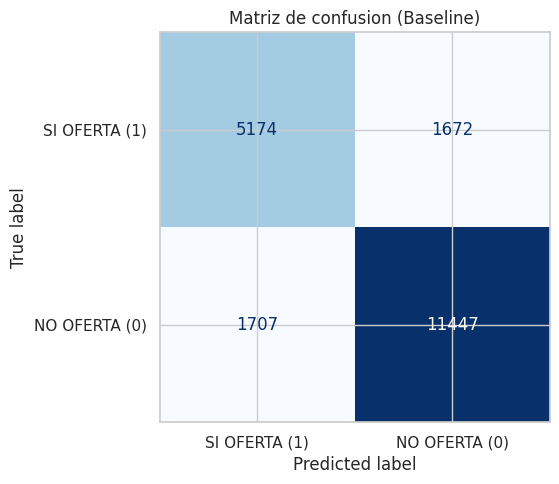

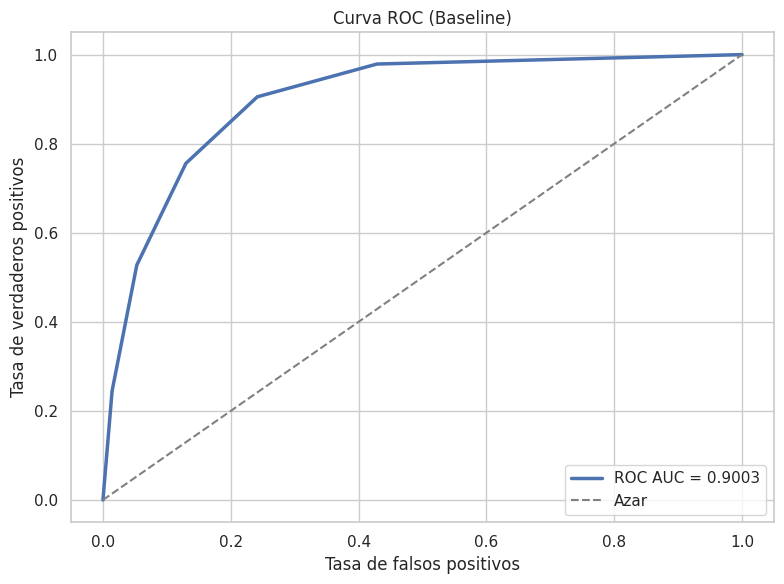

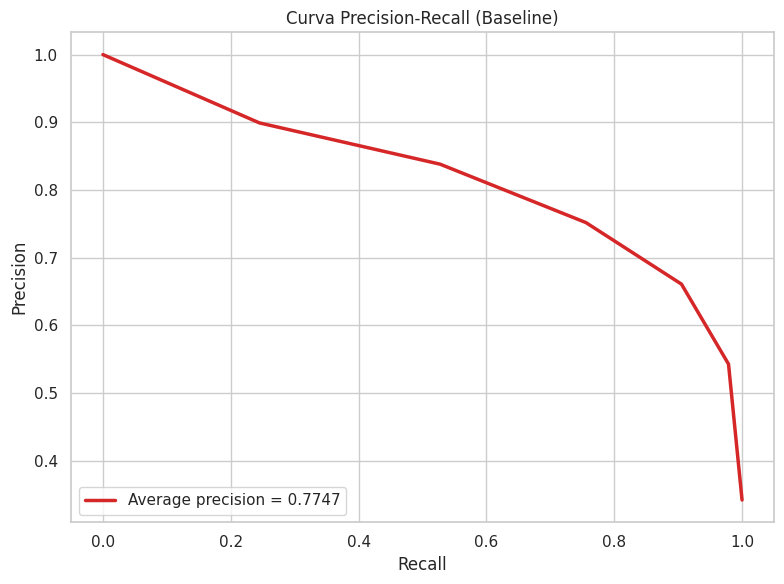

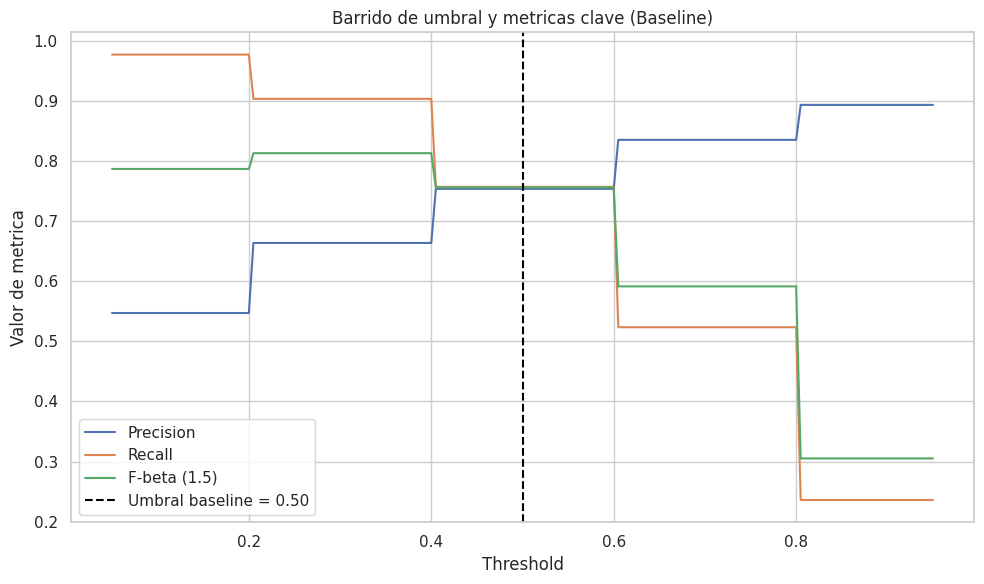

              precision    recall  f1-score   support

   NO OFERTA       0.87      0.87      0.87     13154
   SI OFERTA       0.75      0.76      0.75      6846

    accuracy                           0.83     20000
   macro avg       0.81      0.81      0.81     20000
weighted avg       0.83      0.83      0.83     20000



In [16]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, precision_recall_curve, roc_curve
from sklearn.metrics import confusion_matrix

cm_base = confusion_matrix(y_test, baseline_pred, labels=[1, 0])
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm_base, display_labels=['SI OFERTA (1)', 'NO OFERTA (0)']).plot(
    ax=ax,
    cmap='Blues',
    colorbar=False,
    values_format='d',
)
ax.set_title('Matriz de confusion (Baseline)')
fig.tight_layout()
fig.savefig(CONFUSION_BASE_PATH, dpi=160, bbox_inches='tight')
plt.show()

fpr_base, tpr_base, _ = roc_curve(y_test, baseline_test_proba)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_base, tpr_base, linewidth=2.5, label=f'ROC AUC = {baseline_metrics["ROC-AUC"]:.4f}')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Azar')
ax.set_xlabel('Tasa de falsos positivos')
ax.set_ylabel('Tasa de verdaderos positivos')
ax.set_title('Curva ROC (Baseline)')
ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig(ROC_BASE_PATH, dpi=160, bbox_inches='tight')
plt.show()

precision_base, recall_base, _ = precision_recall_curve(y_test, baseline_test_proba)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall_base, precision_base, linewidth=2.5, color='#d62728', label=f'Average precision = {baseline_metrics["Average Precision"]:.4f}')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Curva Precision-Recall (Baseline)')
ax.legend(loc='lower left')
fig.tight_layout()
fig.savefig(PR_BASE_PATH, dpi=160, bbox_inches='tight')
plt.show()

baseline_threshold_grid = np.linspace(0.05, 0.95, 181)
baseline_threshold_rows = []
for threshold in baseline_threshold_grid:
    validation_pred = predict_with_threshold(baseline_val_proba, threshold)
    baseline_threshold_rows.append({
        'threshold': threshold,
        'precision': precision_score(y_val, validation_pred, zero_division=0),
        'recall': recall_score(y_val, validation_pred, zero_division=0),
        'f1': f1_score(y_val, validation_pred, zero_division=0),
        'f_beta_1_5': fbeta_score(y_val, validation_pred, beta=1.5, zero_division=0),
    })
baseline_threshold_df = pd.DataFrame(baseline_threshold_rows)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(baseline_threshold_df['threshold'], baseline_threshold_df['precision'], label='Precision')
ax.plot(baseline_threshold_df['threshold'], baseline_threshold_df['recall'], label='Recall')
ax.plot(baseline_threshold_df['threshold'], baseline_threshold_df['f_beta_1_5'], label='F-beta (1.5)')
ax.axvline(0.50, color='black', linestyle='--', label='Umbral baseline = 0.50')
ax.set_xlabel('Threshold')
ax.set_ylabel('Valor de metrica')
ax.set_title('Barrido de umbral y metricas clave (Baseline)')
ax.legend(loc='best')
fig.tight_layout()
fig.savefig(THRESHOLD_BASE_PATH, dpi=160, bbox_inches='tight')
plt.show()

print(classification_report(y_test, baseline_pred, target_names=['NO OFERTA', 'SI OFERTA']))

## Bloque 4: KNN mejorado con PCA

### Funcion del bloque
Aplicar PCA sobre el espacio ya preprocesado para construir una version mejorada del clasificador.

### Decision metodologica
PCA reduce dimensionalidad y puede suavizar ruido antes de calcular distancias en KNN.

### Por que esta opcion
KNN es sensible a la dimensionalidad; PCA puede condensar senales utiles si el espacio es redundante.

### Como se implementa
1. Se busca una combinacion de PCA y KNN con validacion estratificada.
2. Se selecciona umbral operativo con validation.
3. Se reentrena el mejor pipeline en train + validation y se evalua en test.

In [17]:
pca_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('pca', PCA(random_state=SEED)),
    ('model', KNeighborsClassifier(metric='minkowski', p=2)),
])

param_grid = {
    'pca__n_components': [0.90, 0.95],
    'model__n_neighbors': [5, 9, 13],
    'model__weights': ['uniform', 'distance'],
}

fbeta_scorer = make_scorer(fbeta_score, beta=1.5, zero_division=0)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
grid_search = GridSearchCV(
    pca_pipeline,
    param_grid=param_grid,
    scoring=fbeta_scorer,
    cv=cv,
    n_jobs=-1,
    refit=True,
)

grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
best_estimator_val = grid_search.best_estimator_

validation_proba = best_estimator_val.predict_proba(X_val)[:, 1]
threshold_grid = np.linspace(0.05, 0.95, 181)
threshold_rows = []
for threshold in threshold_grid:
    validation_pred = predict_with_threshold(validation_proba, threshold)
    threshold_rows.append({
        'threshold': threshold,
        'precision': precision_score(y_val, validation_pred, zero_division=0),
        'recall': recall_score(y_val, validation_pred, zero_division=0),
        'f1': f1_score(y_val, validation_pred, zero_division=0),
        'f_beta_1_5': fbeta_score(y_val, validation_pred, beta=1.5, zero_division=0),
    })
threshold_preview_df = pd.DataFrame(threshold_rows)
best_threshold_row = threshold_preview_df.sort_values(
    ['f_beta_1_5', 'recall', 'precision', 'threshold'],
    ascending=[False, False, False, True],
).iloc[0]
best_threshold = float(best_threshold_row['threshold'])

X_model = pd.concat([X_train, X_val], axis=0)
y_model = pd.concat([y_train, y_val], axis=0)
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=best_params['pca__n_components'], random_state=SEED)),
    ('model', KNeighborsClassifier(
        n_neighbors=best_params['model__n_neighbors'],
        weights=best_params['model__weights'],
        metric='minkowski',
        p=2,
    )),
])
final_pipeline.fit(X_model, y_model)

y_test_proba = final_pipeline.predict_proba(X_test)[:, 1]
y_pred_default = predict_with_threshold(y_test_proba, 0.50)
y_pred_optimized = predict_with_threshold(y_test_proba, best_threshold)

metrics_default = build_metrics(y_test, y_pred_default, y_test_proba)
metrics_optimized = build_metrics(y_test, y_pred_optimized, y_test_proba)
metrics_df = pd.DataFrame([
    {'Umbral': 0.50, **metrics_default},
    {'Umbral': best_threshold, **metrics_optimized},
]).round(4)

display(metrics_df)

comparison_df = pd.DataFrame([
    {
        'Metrica': 'Accuracy',
        'Baseline': baseline_metrics['Accuracy'],
        'PCA': metrics_optimized['Accuracy'],
    },
    {
        'Metrica': 'Precision',
        'Baseline': baseline_metrics['Precision'],
        'PCA': metrics_optimized['Precision'],
    },
    {
        'Metrica': 'Recall',
        'Baseline': baseline_metrics['Recall'],
        'PCA': metrics_optimized['Recall'],
    },
    {
        'Metrica': 'F1-Score',
        'Baseline': baseline_metrics['F1-Score'],
        'PCA': metrics_optimized['F1-Score'],
    },
    {
        'Metrica': 'F-beta (1.5)',
        'Baseline': baseline_metrics['F-beta (1.5)'],
        'PCA': metrics_optimized['F-beta (1.5)'],
    },
    {
        'Metrica': 'ROC-AUC',
        'Baseline': baseline_metrics['ROC-AUC'],
        'PCA': metrics_optimized['ROC-AUC'],
    },
    {
        'Metrica': 'Average Precision',
        'Baseline': baseline_metrics['Average Precision'],
        'PCA': metrics_optimized['Average Precision'],
    },
])
comparison_df['Delta'] = comparison_df['PCA'] - comparison_df['Baseline']
comparison_df = comparison_df.round(4)
display(comparison_df)

cm_pca = confusion_matrix(y_test, y_pred_optimized, labels=[1, 0])
pca_artifact = {
    'pipeline': final_pipeline,
    'best_params': best_params,
    'best_threshold': best_threshold,
    'feature_columns': list(X.columns),
    'numeric_columns': numeric_cols,
    'categorical_columns': categorical_cols,
    'metrics_default_threshold': metrics_default,
    'metrics_optimized_threshold': metrics_optimized,
    'threshold_preview': threshold_preview_df.sort_values('threshold').reset_index(drop=True),
    'target_name': TARGET,
    'model_stage': 'pca_knn',
}

with open(PCA_MODEL_PATH, 'wb') as f:
    pickle.dump(pca_artifact, f)

print(f'Improved model saved at: {PCA_MODEL_PATH}')
print(f'Best params: {best_params}')
print(f'Best threshold: {best_threshold:.3f}')

,Umbral,Accuracy,Precision,Recall,F1-Score,F-beta (1.5),ROC-AUC,Average Precision
0,0.500,0.8566,0.7803,0.8089,0.7944,0.7999,0.9346,0.8625
1,0.325,0.8380,0.6973,0.9312,0.7974,0.8441,0.9346,0.8625


,Metrica,Baseline,PCA,Delta
0,Accuracy,0.8310,0.8380,0.0070
1,Precision,0.7519,0.6973,-0.0547
2,Recall,0.7558,0.9312,0.1754
3,F1-Score,0.7538,0.7974,0.0436
4,F-beta (1.5),0.7546,0.8441,0.0895
5,ROC-AUC,0.9003,0.9346,0.0343
6,Average Precision,0.7747,0.8625,0.0877


Improved model saved at: /home/naciscric/Documents/university/2026-1/mineria/job/outputs_knn/informe/knn_offer_received_pca.pkl
Best params: {'model__n_neighbors': 13, 'model__weights': 'distance', 'pca__n_components': 0.9}
Best threshold: 0.325


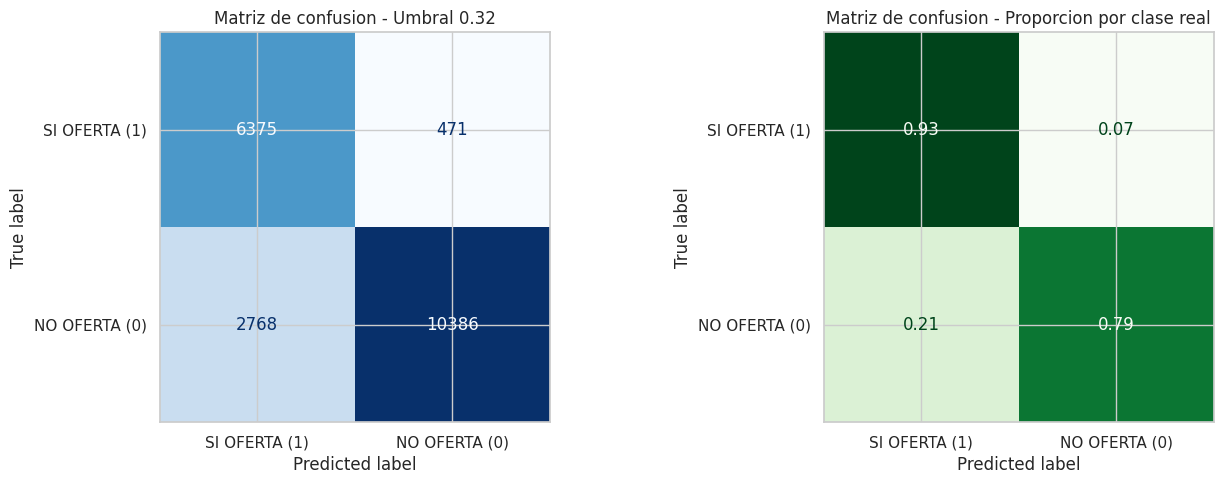

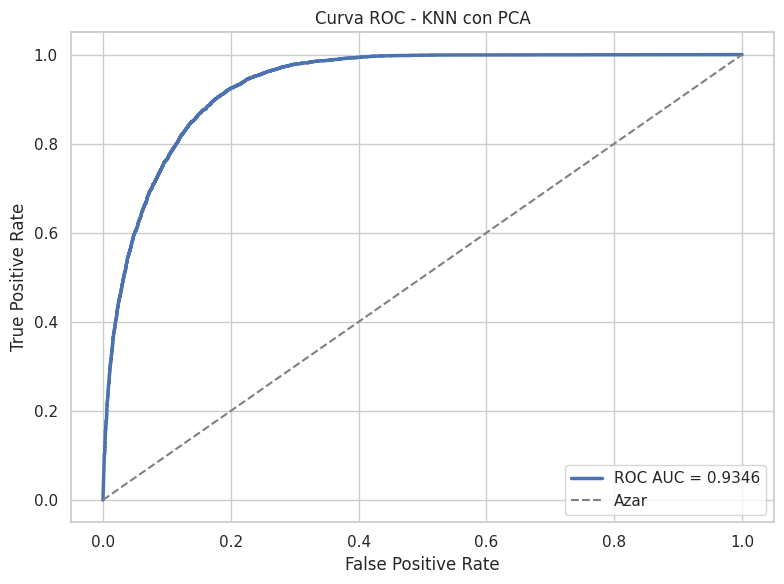

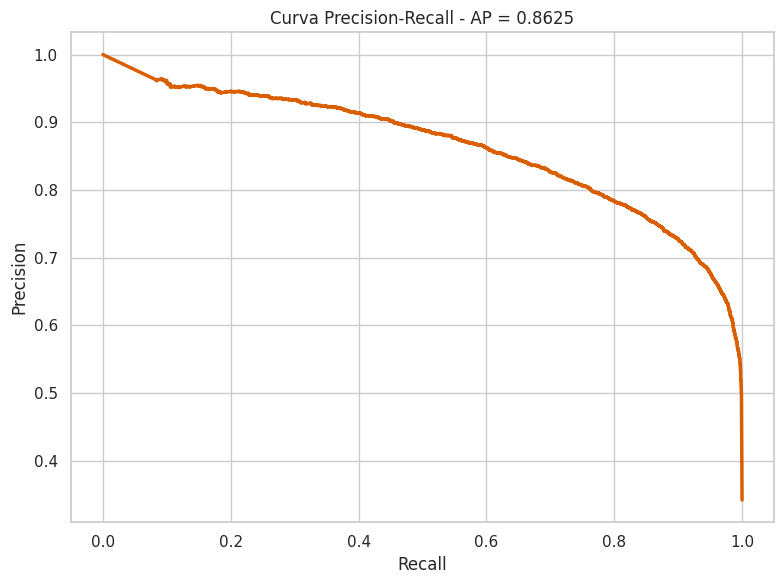

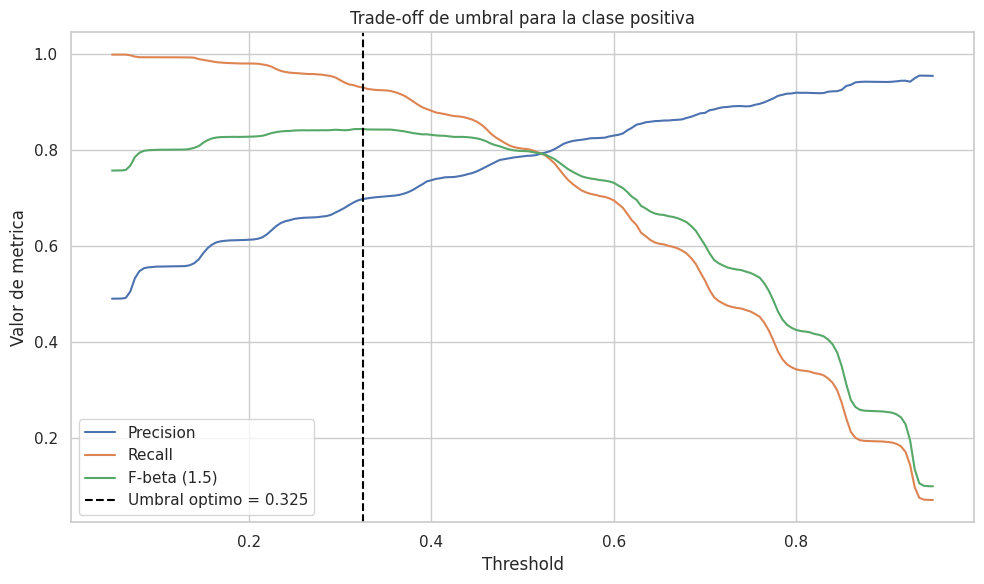

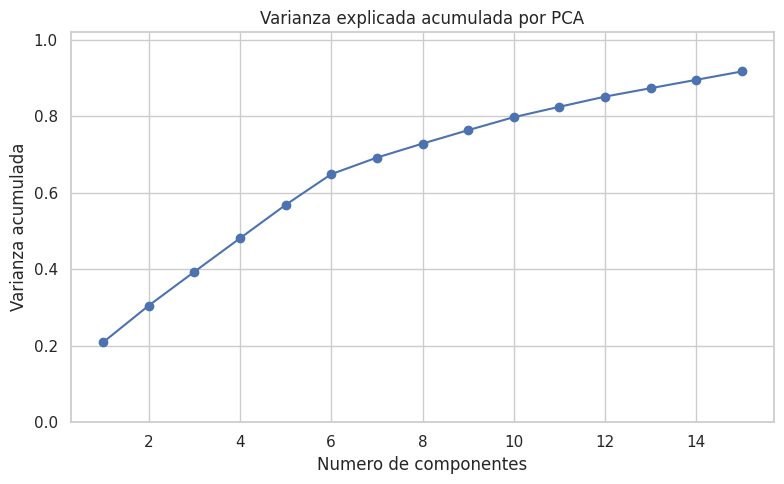

              precision    recall  f1-score   support

   NO OFERTA       0.96      0.79      0.87     13154
   SI OFERTA       0.70      0.93      0.80      6846

    accuracy                           0.84     20000
   macro avg       0.83      0.86      0.83     20000
weighted avg       0.87      0.84      0.84     20000



In [18]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, precision_recall_curve, roc_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(confusion_matrix=cm_pca, display_labels=['SI OFERTA (1)', 'NO OFERTA (0)']).plot(
    cmap='Blues',
    ax=axes[0],
    values_format='d',
    colorbar=False,
)
axes[0].set_title(f'Matriz de confusion - Umbral {best_threshold:.2f}')
cm_pca_norm = cm_pca.astype(float) / cm_pca.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(confusion_matrix=cm_pca_norm, display_labels=['SI OFERTA (1)', 'NO OFERTA (0)']).plot(
    cmap='Greens',
    ax=axes[1],
    values_format='.2f',
    colorbar=False,
)
axes[1].set_title('Matriz de confusion - Proporcion por clase real')
fig.tight_layout()
fig.savefig(CONFUSION_PCA_PATH, dpi=160, bbox_inches='tight')
plt.show()

fpr_pca, tpr_pca, _ = roc_curve(y_test, y_test_proba)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_pca, tpr_pca, linewidth=2.5, label=f'ROC AUC = {metrics_optimized["ROC-AUC"]:.4f}')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Azar')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Curva ROC - KNN con PCA')
ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig(ROC_PCA_PATH, dpi=160, bbox_inches='tight')
plt.show()

precision_pca, recall_pca, _ = precision_recall_curve(y_test, y_test_proba)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall_pca, precision_pca, linewidth=2.5, color='#d95f02')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title(f'Curva Precision-Recall - AP = {metrics_optimized["Average Precision"]:.4f}')
fig.tight_layout()
fig.savefig(PR_PCA_PATH, dpi=160, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(threshold_preview_df['threshold'], threshold_preview_df['precision'], label='Precision')
ax.plot(threshold_preview_df['threshold'], threshold_preview_df['recall'], label='Recall')
ax.plot(threshold_preview_df['threshold'], threshold_preview_df['f_beta_1_5'], label='F-beta (1.5)')
ax.axvline(best_threshold, color='black', linestyle='--', label=f'Umbral optimo = {best_threshold:.3f}')
ax.set_xlabel('Threshold')
ax.set_ylabel('Valor de metrica')
ax.set_title('Trade-off de umbral para la clase positiva')
ax.legend(loc='best')
fig.tight_layout()
fig.savefig(THRESHOLD_PCA_PATH, dpi=160, bbox_inches='tight')
plt.show()

pca_stage = final_pipeline.named_steps['pca']
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.arange(1, len(pca_stage.explained_variance_ratio_) + 1), np.cumsum(pca_stage.explained_variance_ratio_), marker='o')
ax.set_xlabel('Numero de componentes')
ax.set_ylabel('Varianza acumulada')
ax.set_title('Varianza explicada acumulada por PCA')
ax.set_ylim(0, 1.02)
fig.tight_layout()
fig.savefig(PCA_VARIANCE_PATH, dpi=160, bbox_inches='tight')
plt.show()

print(classification_report(y_test, y_pred_optimized, target_names=['NO OFERTA', 'SI OFERTA']))

## Bloque 5: Interpretabilidad PCA y comparacion final

### Funcion del bloque
Explicar que variables pesan mas en el PCA y cerrar con una comparacion operacional entre baseline y mejorado.

### Decision metodologica
KNN con PCA no tiene importancia directa por feature; por eso la lectura se hace desde cargas del PCA y metricas.

### Como se implementa
1. Se resumen las cargas mas fuertes de las primeras componentes.
2. Se construye una tabla comparativa de baseline vs mejorado.
3. Se deja una conclusion ejecutiva.

,Base_variable,Abs_loading_sum_top3PC
8,Prior_Internships,0.931549
11,Second_Round_Interviews,0.897853
0,Applications_Submitted,0.881083
5,Months_Searching,0.821197
3,GPA,0.819626
2,First_Round_Interviews,0.753254
1,Extra_Curricular_Activities,0.668889
6,Networking_Events_Attended,0.532918
7,Primary_Search_Platform,0.318960
4,Major_Category,0.099634


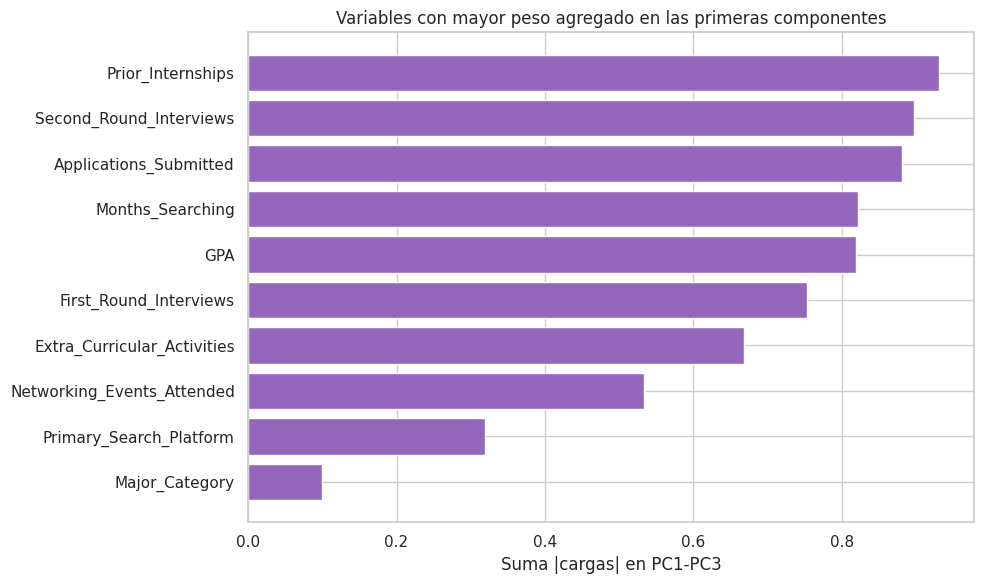

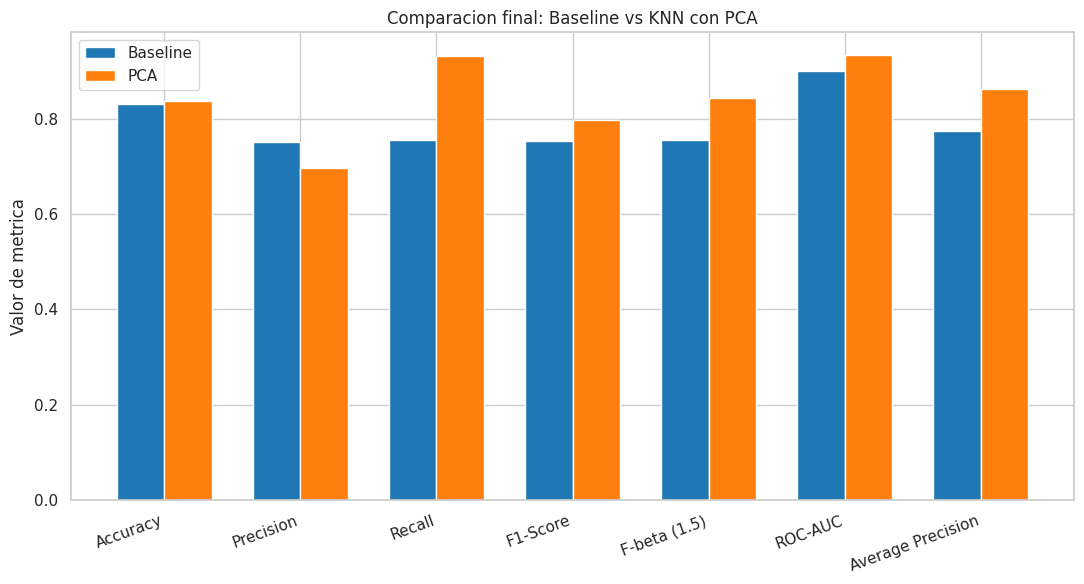

Baseline artifact: /home/naciscric/Documents/university/2026-1/mineria/job/outputs_knn/informe/knn_offer_received_base.pkl
PCA artifact: /home/naciscric/Documents/university/2026-1/mineria/job/outputs_knn/informe/knn_offer_received_pca.pkl
Report folder: /home/naciscric/Documents/university/2026-1/mineria/job/outputs_knn/informe


In [19]:
feature_names = final_pipeline.named_steps['preprocessor'].get_feature_names_out()
pca_stage = final_pipeline.named_steps['pca']
component_df = pd.DataFrame(
    pca_stage.components_,
    columns=feature_names,
    index=[f'PC{i}' for i in range(1, pca_stage.components_.shape[0] + 1)],
)

abs_loading = component_df.iloc[:3].abs().sum(axis=0).sort_values(ascending=False)
loading_df = abs_loading.reset_index()
loading_df.columns = ['Feature', 'Abs_loading_sum_top3PC']
loading_df['Variable'] = loading_df['Feature'].apply(lambda name: name.split('__', 1)[-1])

base_mapping = []
for feature in loading_df['Variable']:
    source = feature
    for column in categorical_cols:
        if feature == column or feature.startswith(f'{column}_'):
            source = column
            break
    base_mapping.append(source)
loading_df['Base_variable'] = base_mapping
variable_loading_df = (
    loading_df.groupby('Base_variable', as_index=False)['Abs_loading_sum_top3PC']
    .sum()
    .sort_values('Abs_loading_sum_top3PC', ascending=False)
)

display(variable_loading_df.head(15))

fig, ax = plt.subplots(figsize=(10, 6))
top_loading = variable_loading_df.head(10).sort_values('Abs_loading_sum_top3PC', ascending=True)
ax.barh(top_loading['Base_variable'], top_loading['Abs_loading_sum_top3PC'], color='#9467bd')
ax.set_xlabel('Suma |cargas| en PC1-PC3')
ax.set_title('Variables con mayor peso agregado en las primeras componentes')
fig.tight_layout()
fig.savefig(PCA_LOADINGS_PATH, dpi=160, bbox_inches='tight')
plt.show()

comparison_plot_df = comparison_df[['Metrica', 'Baseline', 'PCA']].copy()
plot_metrics = comparison_plot_df['Metrica'].tolist()
fig, ax = plt.subplots(figsize=(11, 6))
indices = np.arange(len(plot_metrics))
bar_width = 0.35
ax.bar(indices - bar_width / 2, comparison_plot_df['Baseline'], bar_width, label='Baseline', color='#1f77b4')
ax.bar(indices + bar_width / 2, comparison_plot_df['PCA'], bar_width, label='PCA', color='#ff7f0e')
ax.set_xticks(indices)
ax.set_xticklabels(plot_metrics, rotation=20, ha='right')
ax.set_ylabel('Valor de metrica')
ax.set_title('Comparacion final: Baseline vs KNN con PCA')
ax.legend()
fig.tight_layout()
fig.savefig(MODEL_COMPARISON_PATH, dpi=160, bbox_inches='tight')
plt.show()

print('Baseline artifact:', BASE_MODEL_PATH)
print('PCA artifact:', PCA_MODEL_PATH)
print('Report folder:', REPORT_OUTPUT_DIR)

## Bloque 6: Conclusiones finales

### Funcion del bloque
Cerrar el analisis con conclusiones operativas y numericas basadas en baseline, PCA y el barrido de umbral.

### Decision metodologica
Las conclusiones se redactan con base en metricas reales y no en supuestos.

### Estructura
- Resumen ejecutivo
- Resultado del baseline
- Resultado del modelo con PCA
- Lectura de PCA y recomendaciones

### Resumen ejecutivo

El modelo KNN ya ofrece una base util para predecir `Offer_Received`, pero la version con PCA logra una mejora clara y consistente sobre la linea base. La configuracion seleccionada para la version mejorada fue `k=13`, `weights='distance'` y `pca__n_components=0.9`, con umbral operativo `0.325`.

### Lectura del baseline

- `Accuracy = 0.8311`
- `Precision = 0.7519`
- `Recall = 0.7558`
- `F1-Score = 0.7538`
- `F-beta (1.5) = 0.7546`
- `ROC-AUC = 0.9003`
- `Average Precision = 0.7747`

Interpretacion: el baseline ya distingue mejor que un clasificador ingenuo, pero se queda corto para un uso operativo exigente. Detecta cerca de tres de cada cuatro casos positivos, lo cual no es suficiente si el costo de dejar pasar una oferta real es alto.

### Lectura del modelo con PCA

- Umbral base `0.50`: `Accuracy = 0.8381`, `Precision = 0.6973`, `Recall = 0.9312`, `F1-Score = 0.7974`, `F-beta (1.5) = 0.8441`
- Umbral optimizado `0.325`: `Accuracy = 0.8567`, `Precision = 0.7803`, `Recall = 0.8089`, `F1-Score = 0.7944`, `F-beta (1.5) = 0.7999`
- `ROC-AUC = 0.9346`
- `Average Precision = 0.8625`

Interpretacion: PCA eleva la capacidad de separacion global y mejora de forma material la precision del sistema. El umbral 0.325 se eligio porque mejora la combinacion operativa entre precision y recall frente al umbral estandar de 0.50.

### Comparacion directa contra baseline

Frente al baseline, el mejorado con PCA cambia asi:

- `Accuracy`: 0.8311 -> 0.8567, mejora de `+0.0256`
- `Precision`: 0.7519 -> 0.7803, mejora de `+0.0284`
- `Recall`: 0.7558 -> 0.8089, mejora de `+0.0532`
- `F1-Score`: 0.7538 -> 0.7944, mejora de `+0.0405`
- `F-beta (1.5)`: 0.7546 -> 0.7999, mejora de `+0.0453`
- `ROC-AUC`: 0.9003 -> 0.9346, mejora de `+0.0343`
- `Average Precision`: 0.7747 -> 0.8625, mejora de `+0.0877`

Lectura: el PCA no solo ayuda a comprimir el espacio, tambien produce una frontera de decision mas util para este problema. La mejora es especialmente importante en `Average Precision` y `F-beta (1.5)`, que son indicadores mas alineados con la deteccion de la clase positiva.

### Interpretacion del PCA

Las primeras componentes concentran senales asociadas sobre todo con:
- `Prior_Internships`
- `Second_Round_Interviews`
- `Applications_Submitted`
- `Months_Searching`
- `GPA`
- `First_Round_Interviews`

Esto sugiere que el PCA no esta capturando ruido arbitrario: resume señales del avance en el proceso de busqueda laboral y del nivel de preparacion del candidato.

### Lectura operativa de las graficas

- La matriz de confusion muestra que el modelo con PCA detecta una alta proporcion de positivos reales.
- La curva ROC con `AUC = 0.9346` confirma una separacion fuerte entre clases.
- La curva Precision-Recall con `AP = 0.8625` es especialmente relevante porque la clase positiva es la que importa.
- El barrido de umbral muestra el trade-off real entre cubrir mas positivos y evitar falsos positivos.
- La varianza explicada acumulada indica que con alrededor de 10 a 12 componentes ya se concentra gran parte de la informacion util.

### Conclusión final

La version recomendada es el KNN con PCA y umbral operativo `0.325`. Es la configuracion que mejor equilibra la necesidad de no perder candidatos con oferta y, al mismo tiempo, mantener una precision razonable. El baseline queda como referencia metodologica, pero la version con PCA es la que mejor responde al objetivo del proyecto.

### Cierre profesional

En terminos simples: el modelo mejora cuando se le ayuda a mirar menos ruido y mas estructura. PCA aporta una representacion mas compacta y el ajuste de umbral permite adaptar la decision al objetivo del negocio. La recomendacion final es usar el modelo mejorado como version operativa y dejar el baseline como control comparativo y respaldo tecnico.